En Pandas, la agrupación + la agregación...En la agrupación las dimensiones y en la agregación la metrica...Siempre sobre un dato numerico, texto solo puedo contar. la metrica es la medicion de la información
Pais - Importe 

In [ ]:
#0.- importar librerias
import pandas as pd
from datetime import date, datetime, timedelta
#1.- cargar un dataframe, si hay +1 hoja el parametro sheet_name="Hoja3"
datos_pedidos = pd.read_excel(r"C:\Users\formacio\Downloads\Datos Pedidos.xlsx", sheet_name="Datos")
#2.- Asegurarme que la columna/campo "Fecha de Pedido" es datetime
datos_pedidos['Fecha de Pedido'] = pd.to_datetime(datos_pedidos['Fecha de Pedido'])
#3.- Agrupar por pais para ver la suma de importe
datos_pedidos.groupby(['Pais']).Importe.sum()
#4.- Agrupar por pais para ver el promedio de importe
round(datos_pedidos.groupby(['Pais']).Importe.mean(),2)
#5.- Agrupar por 2 dimensiones, el importe mas grande
datos_pedidos.groupby(['Pais','Ciudad']).Importe.max()
datos_pedidos.groupby(['Pais','Ciudad'])['Importe'].max()
#6.- Ver el importe mas pequeño por categoria
datos_pedidos.groupby(['Categoria']).Importe.min()
#7.- Ver el numero de veces que repite una dimension (tabla de frecuencias) o value_counts
datos_pedidos.groupby(['Ciudad']).Ciudad.count()

In [ ]:
#Si quiero tener en una agrupación varias agregaciones, usaremos agg
datos_pedidos.groupby(['Pais']).agg(
    suma_importe = ('Importe','sum'),
    promedio_cantidad =('Cantidad','mean'),
    total_pedidos = ('Importe', 'count')
).reset_index()

In [ ]:
#Como visualizar los primeros n elementos mas grandes
datos_agrupados = datos_pedidos.groupby(['Pais']).agg(
    suma_importe = ('Importe','sum'),
    promedio_cantidad =('Cantidad','mean'),
    total_pedidos = ('Importe', 'count')
).reset_index()
#Queremos ver los 4 paises que mas suma de importe tienen
datos_agrupados.nlargest(4,'suma_importe')
#Queremos ver los 4 paises que menos numero de pedidos tienen
datos_agrupados[['Pais','total_pedidos']].nsmallest(4,'total_pedidos')


In [ ]:
#Como averiguar el numero de registros o filas que tiene un dataframe
#Opción A - len (me devuelve numero)
len(datos_agrupados)
#Opción B, muestra todo por columna
datos_agrupados.count()
#Opción C con shape (me devuelve numero)
datos_agrupados.shape[0]

Practica 32: Partiendo del fichero de excel "Datos Pedidos.xlsx", cargar un dataframe y resolver el siguiente enunciado:
- Ver la suma de importe, promedio de cantidad e importe mas grande, por Pais y Ciudad
- Ver los 3 Paises que mas suma de importe tienen y averiguar la suma total de importe de estos 3 paises (Ver en un texto)
- Ver la suma de importe del resto de paises que no son los 3 que mas (Ver en un texto)
- Concatenar estos 2 datos, para ver por un lado el importe de los 3 paises que mas y por otro el importe del resto de paises, calcular que % representa cada uno del total en una columna nueva.

In [ ]:
#Solución practica 32
#0.- importar librerias
import pandas as pd
#1.- cargar un dataframe, si hay +1 hoja el parametro sheet_name="Hoja3"
datos_pedidos = pd.read_excel(r"C:\Users\formacio\Downloads\Datos Pedidos.xlsx", sheet_name="Datos")
#2.- En un dataframe ver la agrupación + agregación solicitada
datos_agrupados = datos_pedidos.groupby(['Pais','Ciudad']).agg(
    total_importe = ('Importe','sum'),
    promedio_cantidad = ('Cantidad','mean'),
    importe_max = ('Importe', 'max')
).reset_index()
datos_agrupados
#3.- Ver los 3 paises que mas total_importe tienen mas la suma de estos 3
datos_agrupados_3lar= datos_pedidos.groupby(['Pais'])['Importe'].sum().reset_index()
datos_agrupados_3lar = datos_agrupados_3lar.nlargest(3,'Importe')
#Averiguar en un texto la suma de estos 3
print("La suma de importe de los 3 paises que mas tienen es",datos_agrupados_3lar['Importe'].sum())
#4.- Ver el resto de paises que no son los 3 que mas y la suma
datos_agrupados_3nsm = datos_pedidos.groupby(['Pais'])['Importe'].sum().reset_index()
datos_agrupados_3nsm = datos_agrupados_3nsm.nsmallest(len(datos_agrupados_3nsm)-3,'Importe')
print("La suma de importe del resto de paises seria",datos_agrupados_3nsm['Importe'].sum())
#5.- Concatenar en un dataframe los 2 anteriores
datos_finales = pd.concat([datos_agrupados_3lar,datos_agrupados_3nsm],ignore_index=True)
datos_finales
#6.- Añadir el % que representa cada Pais con respecto al total
suma_total = datos_finales['Importe'].sum()
datos_finales['% Importe'] = round((datos_finales['Importe'] / suma_total) * 100, 2)
datos_finales


In [ ]:
datos_pedidos[datos_pedidos['Pais']=='Alemania'].Importe.sum()

Graficos en Python, tenemos 4 librerias:
- matplotlib (graficos sencillos, codigo sencillo, pero suficiente)
- seaborn (gráficos de mas calidad, codigo mas dificil)
- bokeh (similar a matplotlib)
- streamlit (para mostrar graficos en una pagina web)

Se deben instalar las librerias correspondientes
- >pip install matplotlib
Para comprobar haremos >pip list

Para dibujar un grafico en el output de un fichero, tengo que reservar espacio en el kernel, mediante figure, necesito tambien ajustar el tamaño figsize, el tipo de grafico se ajusta con kind
- kind = bar (gráfico de columnas)
- kind = line (gráfico de lineas)
- kind = pie (gráfico circular)
- kind = scatter (gráfico de dispersión)

Se puede generar el grafico, desde la libreria o desde pandas

In [ ]:
!pip install matplotlib

In [ ]:
#Queremos ver un grafico de columnas con el importe por pais
#0.- Llamar a la libreria
import matplotlib.pyplot as plt
#1.- Crear el Dataframe de agrupación de suma de importe por pais
datos_finales = datos_pedidos.groupby(['Pais'])['Importe'].sum().reset_index()
datos_finales
#2.- Reservar espacio en el kernel con figure
plt.figure(figsize=(12,5))
#3.- Vamos a dibujar el grafico de columnas por pais, partiendo del dataframe
datos_finales.plot(kind='bar',x='Pais',y='Importe',color='orange')
#4.- Ajustes del gráfico
plt.title("Importe por pais")
plt.xlabel("Paises")
plt.ylabel("Importe")
#Girar los nombres de los paises 45 grados
plt.xticks(rotation=45)
plt.show()

Practica 33: Partiendo del fichero Pedidos.xlsx + Detalles Pedidos.xlsx + Comerciales.xlsx, crear un grafico de columnas (en color verde) para ver los 5 comerciales que mas importe han vendido, teniendo en cuenta que el importe = Precio Unidad * Cantidad

<Figure size 900x600 with 0 Axes>

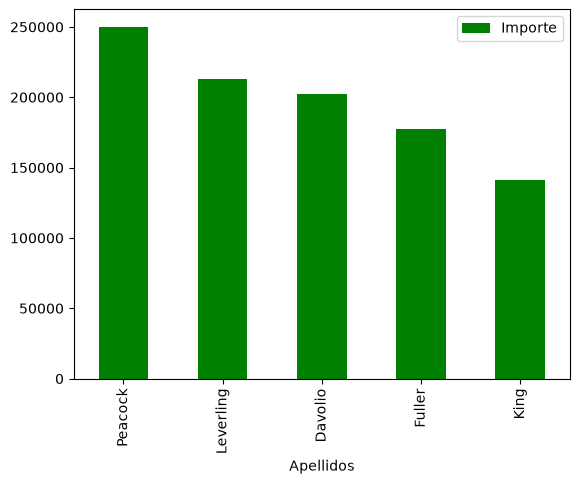

In [37]:
#Solución practica 33
#0.- Importar librerias
import pandas as pd
import matplotlib.pyplot as plt
#1.- Vamos a cargar los 3 dataframes
pedidos = pd.read_excel(r"C:\Users\formacio\Downloads\Pedidos.xlsx")
detalles_pedidos = pd.read_excel(r"C:\Users\formacio\Downloads\Detalles Pedidos.xlsx")
comerciales = pd.read_excel(r"C:\Users\formacio\Downloads\Comerciales.xlsx")
detalles_pedidos
#2.- Hacer el merge todo a la vez
datos = pd.merge(pedidos,detalles_pedidos,on='Id. de pedido',how='inner').merge(comerciales,on='Id. de Comercial',how='inner')
datos
#3.- calcular el importe
datos['Importe'] = round(datos['Precio por unidad'] * datos['Cantidad'],2)
datos
#4.- hacer un dataframe con la agrupación
comerciales_importe = datos.groupby('Apellidos').Importe.sum().reset_index()
comerciales_importe
#5.- Un dataframe con los 5 que mas importe tienen
comerciales_top5 = comerciales_importe.nlargest(5,'Importe')
comerciales_top5
#6.- Configurar gráfico
plt.figure(figsize=(9,6))
comerciales_top5.plot(kind='bar',x='Apellidos',y='Importe',color='green')
plt.show()
#Id. de pedido - Id. de pedido
#Id. de Comercial - Id. de Comercial
#Precio por unidad - Cantidad